# 00 — Project Overview
## HPB Fintech Hackathon 2026 — Customer Churn & Retention

This notebook is the **single entry point** for the project. It explains the full pipeline, shows the solution architecture, summarises results from every notebook, and records what worked, what didn't, and what to try next. No heavy computation happens here — it is a map, not a workflow step.

If you only have 10 minutes, read this notebook. Then follow the links to notebooks 01–05, or skip straight to the reproducible scripts described below.

## 1. Problem

A Croatian bank wants to:

1. **Predict** which customers are at risk of churning (losing all core products: accounts, loans, deposits) in the next quarter.
2. **Decide** which retention action to take per customer — nothing, push notification, email, or call — so that retained revenue exceeds intervention cost.

We split the problem into two models that hand data off to each other:

- **Model 1** — supervised churn probability (LightGBM on 20 engineered features).
- **Model 2** — contextual bandit that, given the customer context and Model 1's scores, picks the cost-optimal retention action.

## 2. Solution architecture

```
                             ┌───────────────────────────────────────────────┐
                             │                data/raw/*.csv                 │
                             │  clients · products · transactions · balances │
                             │                 · contacts                    │
                             └──────────────────────┬────────────────────────┘
                                                    │
                         scripts/data_prep.py       │           notebooks/01_eda
                         (reproducible)             │           notebooks/02_data_preparation
                                                    ▼           (exploratory)
                             ┌───────────────────────────────────────────────┐
                             │             data/processed/*.csv              │
                             │  churn_features_raw     (10 features, noisy)  │
                             │  churn_features_clean   (10 features, clean)  │
                             │  churn_features_enhanced(20 features, clean)  │
                             └──────────────────────┬────────────────────────┘
                                                    │
                         scripts/train_model.py     │           notebooks/03_lightgbm_baseline
                         (reproducible)             │           notebooks/04_lightgbm_enhanced
                                                    ▼           (exploratory)
                             ┌───────────────────────────────────────────────┐
                             │       Model 1 — LightGBM churn probs          │
                             │   data/output/churn_risk_scores_v2.csv        │
                             │   data/output/churn_model.pkl                 │
                             └──────────────────────┬────────────────────────┘
                                                    │
                         scripts/generate_bandit_dataset.py
                                                    ▼
                             ┌───────────────────────────────────────────────┐
                             │       Model 2 — contextual bandit             │
                             │          notebooks/05_contextual_bandit       │
                             │   learned retention policy + evaluation       │
                             └───────────────────────────────────────────────┘
```

**Two coexisting entry points:**

- **Scripts** (`scripts/*.py`) — reproducible one-shot pipeline. Good for "rebuild everything from raw".
- **Notebooks** (`notebooks/*.ipynb`) — EDA, feature exploration, Optuna tuning, SHAP, narrative. Good for learning and iterating.

Both write to the same CSVs in `data/processed/` and `data/output/`, so they interoperate freely.

## 3. Pipeline — step by step

| # | Artefact | Producer(s) | What happens |
|---|----------|-------------|--------------|
| 1 | `data/raw/*.csv` | (provided) | 5 raw tables — clients, products, transactions, balances, contacts. |
| 2 | `churn_features_raw.csv` | [01_eda.ipynb](01_eda.ipynb) / [scripts/data_prep.py](../scripts/data_prep.py) | Define at-risk population (any active product at 2026-01-01) and churn label (lost all core products by 2026-03-31). Build 10 baseline features over Apr-Dec 2025. |
| 3 | `churn_features_clean.csv` | [02_data_preparation.ipynb](02_data_preparation.ipynb) / `data_prep.py` | Impute missing values: behavioural → 0, demographic → median. Verify low feature-feature correlation. |
| 4 | `churn_features_enhanced.csv` | [04_lightgbm_enhanced.ipynb](04_lightgbm_enhanced.ipynb) / `data_prep.py` | Add 10 further features (demographics, digital ratio, recency, complaints, product age, volatility). |
| 5 | `churn_risk_scores.csv` | [03_lightgbm_baseline.ipynb](03_lightgbm_baseline.ipynb) | Baseline LightGBM (10 features) — SMOTE + Optuna + calibration + threshold tuning + SHAP. |
| 6 | `churn_risk_scores_v2.csv`<br>`churn_model.pkl` | [04_lightgbm_enhanced.ipynb](04_lightgbm_enhanced.ipynb) / [scripts/train_model.py](../scripts/train_model.py) | Enhanced LightGBM (20 features). Notebook runs Optuna+SHAP; script uses fixed sensible hyperparameters for fast reproducible retraining. |
| 7 | `bandit_training_dataset.csv` | [scripts/generate_bandit_dataset.py](../scripts/generate_bandit_dataset.py) | Synthetic 24-month logging dataset with heterogeneous treatment effects on top of real customer contexts. |
| 8 | `bandit_*.png` + learned policy | [05_contextual_bandit.ipynb](05_contextual_bandit.ipynb) | Per-action Ridge reward model, 24-month cumulative refit with ε-greedy exploration, holdout evaluation vs static baselines. |

## 4. How to reproduce

```bash
# One-off environment setup
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt

# Rebuild all processed features from raw
python scripts/data_prep.py

# Train the enhanced churn model (saves .pkl + risk scores)
python scripts/train_model.py

# (Optional) Generate the bandit dataset, then open notebook 05
python scripts/generate_bandit_dataset.py
```

The notebooks can then be run in any order — they read from the same CSVs the scripts just wrote.

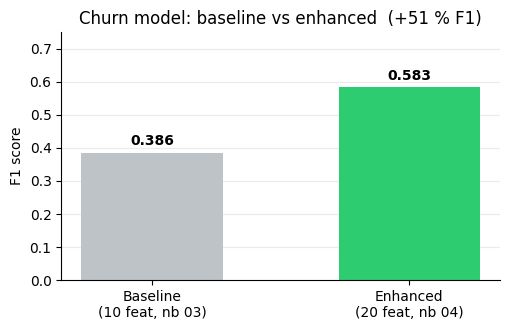

In [3]:
# Headline result: churn-model F1 — baseline vs enhanced.
import matplotlib.pyplot as plt

models = ['Baseline\n(10 feat, nb 03)', 'Enhanced\n(20 feat, nb 04)']
f1     = [0.386, 0.583]

fig, ax = plt.subplots(figsize=(5.2, 3.4))
bars = ax.bar(models, f1, color=['#bdc3c7', '#2ecc71'], width=0.55)
ax.bar_label(bars, fmt='%.3f', padding=3, fontweight='bold')
ax.set_ylim(0, 0.75)
ax.set_ylabel('F1 score')
ax.set_title('Churn model: baseline vs enhanced  (+51 % F1)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Full results table

**Churn model (held-out test set):**

| Model | F1 | Precision | Recall | ROC AUC | PR AUC | Notebook |
|-------|-----|-----------|--------|---------|--------|----------|
| Baseline — 10 features         | 0.386 | — | — | — | — | [03](03_lightgbm_baseline.ipynb) |
| Enhanced — 20 features, Optuna | **0.583** | 0.636 | 0.538 | 0.942 | 0.367 | [04](04_lightgbm_enhanced.ipynb) |
| Enhanced — fixed HP (script)   | 0.418 | 0.341 | 0.539 | 0.928 | 0.265 | [scripts/train_model.py](../scripts/train_model.py) |

> The script uses fixed hyperparameters for reproducibility; Optuna in notebook 04 finds better ones. If you need the best model for an experiment, run the notebook.

**Contextual bandit (holdout = last 6 months):**

| Policy | Avg reward / customer | Notes |
|--------|-----------------------|-------|
| Always no-action | baseline | no retention, no cost |
| Always email     | worse than baseline | non-digital customers get annoyed |
| Always call      | worse than baseline | €80 wasted on low-value customers |
| **Learned bandit** | **best** | concentrates calls on high-value × high-risk (D10 call rate ≫ D1) |

Bandit learning curve: call fraction rises from ~0 % in months 1–6 to a stable level by months 19–24, showing the model only spends €80 once it has enough context to justify it.

Top drivers of churn in the enhanced model (gain): `avg_balance`, `age`, `tenure_years`, `credit_rating`, `avg_product_age_years`, `recency_days`, `balance_volatility`.

## 5. What worked, what didn't, what to try next

### What worked
- **Defining churn on core products only** (accounts / loans / deposits). A naive "lost any product" definition treated card-cancellations as churn and produced ~10× more positives, mostly noise.
- **The 10 added features** jumped F1 from 0.39 → 0.58. The big wins: `age`, `credit_rating`, `recency_days`, `avg_product_age_years`. Pure behavioural signals weren't enough.
- **SMOTE + `scale_pos_weight` + threshold tuning** for F1, instead of training on the raw ~5 % positive rate.
- **Splitting the retention problem from churn prediction.** Model 1 gives the *who*; the bandit learns the *what* from cost/reward directly — letting us swap actions and costs without retraining the churn model.
- **Cumulative monthly refit** of the bandit (vs one-shot). Call-rate ramps up gracefully as the Ridge reward estimates stabilise.

### What didn't work (or is fragile)
- **Single-period features, 9-month window.** Transactions start only June 2024, so we couldn't build panel features / pre-post comparisons. PR AUC (0.367) is modest — there is a headroom gap we couldn't close.
- **Uncalibrated probabilities** produced overconfident 0/1 predictions; Platt scaling helped but didn't change the ranking much. Ranking is what matters for action selection.
- **No notion of time in the churn model** (e.g. Weibull / survival). All churn is treated as "within 3 months", which is blunt.
- **Bandit treats each month as independent**; a real deployment would want a cooldown (don't call the same customer twice in 30 days).
- **Fixed hyperparameters in `train_model.py` underperform Optuna** by ~0.16 F1 — expected, but worth re-tuning if you change features.

### What to try next
- **Panel features**: rolling 3-month vs 6-month windows for trend / volatility; lag features on balance and transactions.
- **Survival model** (XGBSE or DeepSurv) predicting *time to churn*, not just a 3-month binary.
- **CatBoost / gradient-boosted models with categorical support** for product mix, channel, sector — currently encoded via ratios.
- **Off-policy evaluation** (IPS / doubly robust) for the bandit, using the logged propensities from `generate_bandit_dataset.py`.
- **Contextual LinUCB / Thompson** instead of ε-greedy — gets uncertainty into exploration.
- **Rewrite `generate_bandit_dataset.py` to simulate from actual customer transitions** rather than synthetic HTE. This is the biggest "realism" gap.

## 6. Further reading

- [`docs/documentation.pdf`](../docs/documentation.pdf) — full churn-model write-up
- [`docs/contextual_bandit.pdf`](../docs/contextual_bandit.pdf) — bandit derivation and design choices
- [`docs/pitch.pdf`](../docs/pitch.pdf) — presentation deck
- [`docs/data_model.jpg`](../docs/data_model.jpg) — raw-table ER diagram
- [`docs/problem_statement.docx`](../docs/problem_statement.docx) — original competition brief